In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import copy
from datetime import datetime, timedelta
from keras.utils import to_categorical
# import visualkeras
# import tensorflow as tf
from sklearn.metrics import balanced_accuracy_score
import optuna
from optuna.samplers import TPESampler
import keras
from keras.callbacks import ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import sys
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import glob 

sys.path.append("/glade/u/home/jhayron/WR_Predictability/3_MLModels/")
from model_builders_v2 import *
from sklearn import datasets, ensemble
from sklearn.model_selection import RandomizedSearchCV

2024-06-03 11:28:10.974532: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
/glade/work/jhayron/conda-envs/cnn_wr/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load outputs

In [3]:
week_out=0
week_out_str = f'week{week_out}'

wr_series = pd.read_csv('/glade/work/jhayron/Data4Predictability/WR_Series_20231120.csv',\
                index_col=0,names=['week0'],skiprows=1,parse_dates=True)
for wk in range(2,10):
    series_temp = copy.deepcopy(wr_series["week0"])
    series_temp.index = series_temp.index - timedelta(weeks = wk-1)
    series_temp.name = f'week{wk-1}'
    if wk==2:
        df_shifts = pd.concat([pd.DataFrame(wr_series["week0"]),pd.DataFrame(series_temp)],axis=1)  
    else:
        df_shifts = pd.concat([df_shifts,pd.DataFrame(series_temp)],axis=1)

In [4]:
mean_freq = df_shifts['week0'].dropna().value_counts().sort_index()
mean_freq = mean_freq / np.sum(mean_freq)

# Trends in frequency of the WRs

In [5]:
initial_df = df_shifts['week0'].dropna()

In [6]:
center_years = np.arange(1983,2019,3)
freqs = np.zeros([5,len(center_years)])
freqs_anoms = np.zeros([5,len(center_years)])
for iyear,year in enumerate(center_years):
    df_temp = initial_df[(initial_df.index.year>=year-2)&(initial_df.index.year<=year+2)]
    freq_temp = df_temp.dropna().value_counts().sort_index()
    freq_temp = freq_temp / np.sum(freq_temp)
    freqs[:,iyear] = freq_temp
    freqs_anoms[:,iyear] = freq_temp-mean_freq

Text(0.0, 1.0, 'Long-term change in frequency with time')

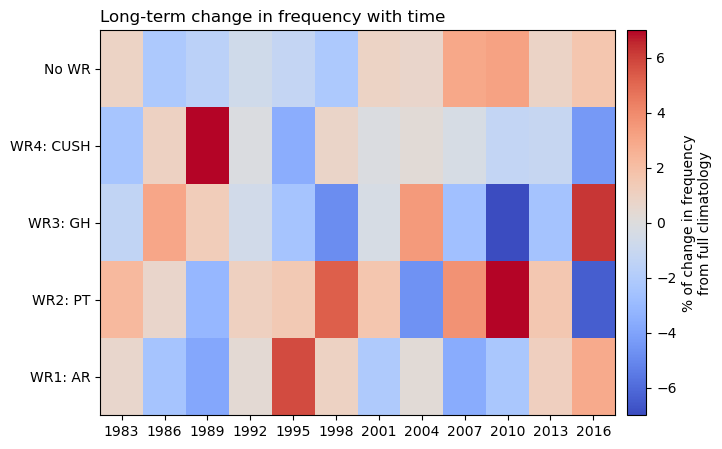

In [7]:
names_wr = ["WR1: AR", "WR2: PT", "WR3: GH", "WR4: CUSH", "No WR"]
fig, ax1 = plt.subplots(figsize=(8,5))
cm = ax1.pcolormesh(center_years,names_wr,freqs_anoms*100,
                    vmin=-7,vmax=7,cmap='coolwarm')
ax1.set_xticks(center_years)

cbar = plt.colorbar(cm,pad=0.02)
cbar.set_label('% of change in frequency\nfrom full climatology')
plt.title('Long-term change in frequency with time',loc='left')

# Trends in frequency of the WRs

In [9]:
indices_seasons = {'Winter':[12,1,2],
                   'Spring':[3,4,5],
                   'Summer':[6,7,8],
                   'Fall':[9,10,11]}

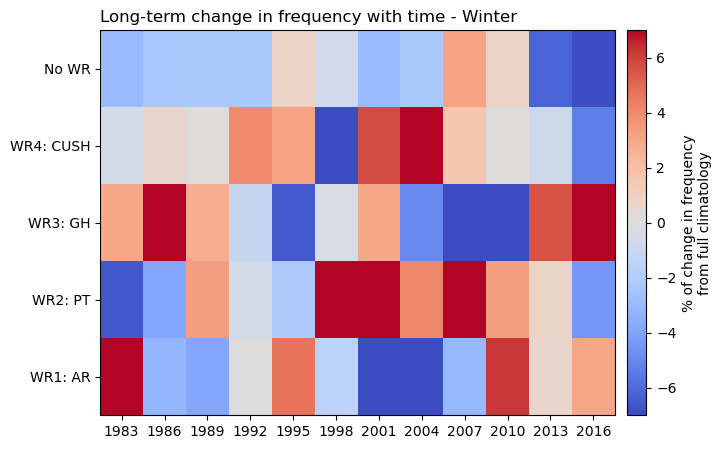

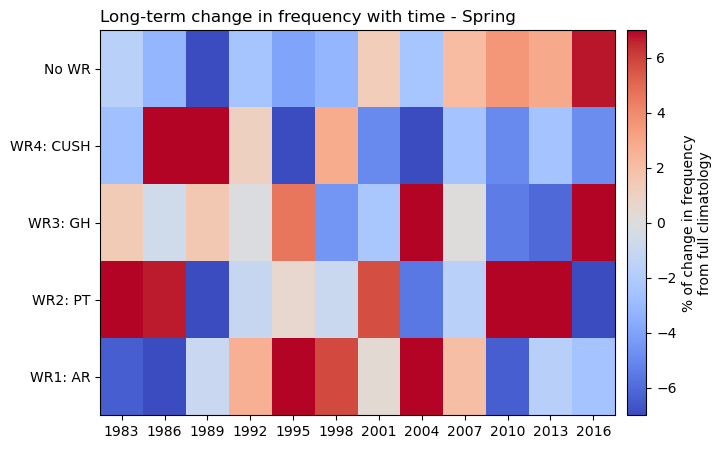

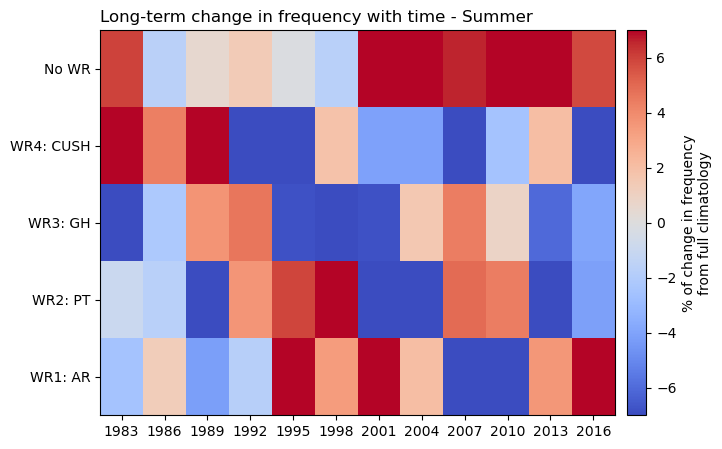

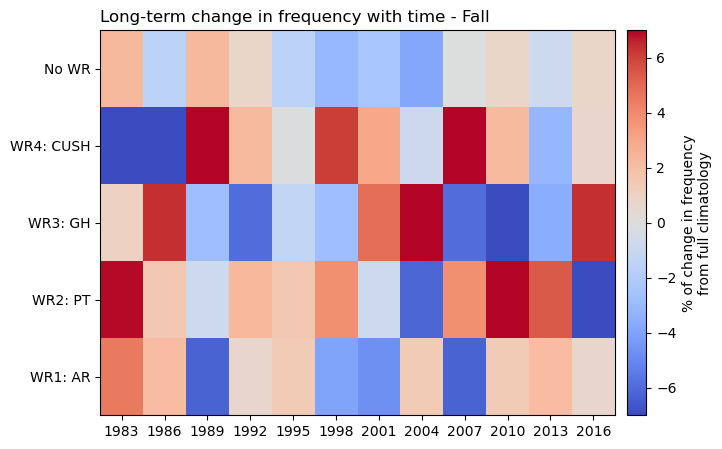

In [10]:
for season in indices_seasons.keys():
    initial_df = df_shifts['week0'].dropna()
    
    initial_df = initial_df[(initial_df.index.month==indices_seasons[season][0])|\
                            (initial_df.index.month==indices_seasons[season][1])|\
                            (initial_df.index.month==indices_seasons[season][2])]
    
    center_years = np.arange(1983,2019,3)
    freqs = np.zeros([5,len(center_years)])
    freqs_anoms = np.zeros([5,len(center_years)])
    for iyear,year in enumerate(center_years):
        df_temp = initial_df[(initial_df.index.year>=year-2)&(initial_df.index.year<=year+2)]
        freq_temp = df_temp.dropna().value_counts().sort_index()
        freq_temp = freq_temp / np.sum(freq_temp)
        freqs[:,iyear] = freq_temp
        freqs_anoms[:,iyear] = freq_temp-mean_freq
    names_wr = ["WR1: AR", "WR2: PT", "WR3: GH", "WR4: CUSH", "No WR"]
    fig, ax1 = plt.subplots(figsize=(8,5))
    cm = ax1.pcolormesh(center_years,names_wr,freqs_anoms*100,
                        vmin=-7,vmax=7,cmap='coolwarm')
    ax1.set_xticks(center_years)
    
    cbar = plt.colorbar(cm,pad=0.02)
    cbar.set_label('% of change in frequency\nfrom full climatology')
    plt.title(f'Long-term change in frequency with time - {season}',loc='left')
    plt.show()
    plt.close('all')


# Trends in persistence

In [217]:
monday_df = initial_df[initial_df.index.day_of_week==0]
thursday_df = initial_df[initial_df.index.day_of_week==3]

In [218]:
def get_durations_histogram(df):
    # Initialize variables
    current_class = df.iloc[0]
    current_duration = 1
    durations = []

    # Calculate durations
    for i in range(1, len(df)):
        if df.iloc[i] == current_class:
            current_duration += 1
        else:
            durations.append([current_class, current_duration])
            current_class = df.iloc[i]
            current_duration = 1

    # Append the final duration
    durations.append((current_class, current_duration))
    durations = pd.DataFrame(durations,columns=['class','duration'])
    
    bins = np.arange(0.5,12.5,1)
    mid_bins = bins[:-1]+0.5
    durations = durations[durations['class']!=4]
    hist = np.histogram(durations['duration'],bins=bins)[0]
    # hist = hist/np.sum(hist)
    return hist
    # print(durations)

In [219]:
bins = np.arange(0.5,12.5,1)
mid_bins = bins[:-1]+0.5
hist_monday = get_durations_histogram(monday_df)
hist_thursday = get_durations_histogram(thursday_df)
hist_total = hist_monday+hist_thursday
hist_total = hist_total/np.sum(hist_total)

In [220]:
center_years = np.arange(1987,2015,5)
center_years

array([1987, 1992, 1997, 2002, 2007, 2012])

Text(0.0, 1.0, 'Long-term change in persistence of WRs with time\n11-year window')

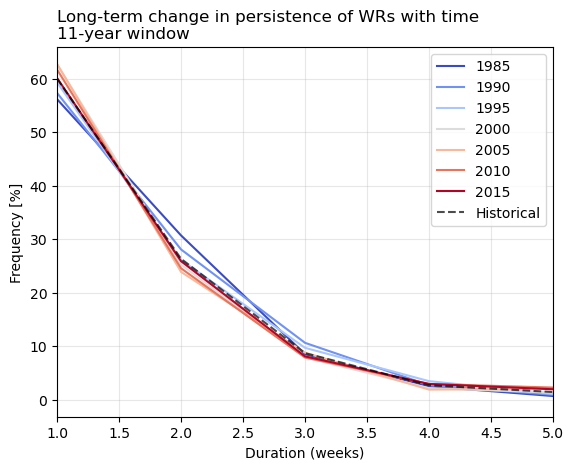

In [221]:
center_years = np.arange(1985,2020,5)
hist_durations = np.zeros([len(mid_bins),len(center_years)])

for iyear,year in enumerate(center_years):
    df_temp = initial_df[(initial_df.index.year>=year-5)&(initial_df.index.year<=year+5)]
    
    monday_df = df_temp[df_temp.index.day_of_week==0]
    thursday_df = df_temp[df_temp.index.day_of_week==3]
    
    hist_monday = get_durations_histogram(monday_df)
    hist_thursday = get_durations_histogram(thursday_df)
    hist_temp = hist_monday+hist_thursday
    hist_temp = hist_temp/np.sum(hist_temp)
    
    hist_durations[:,iyear] = hist_temp
    
n = len(center_years)
colors = plt.cm.coolwarm(np.linspace(0,1,n))

for iyear,year in enumerate(center_years):
    plt.plot(mid_bins,hist_durations[:,iyear]*100,color=colors[iyear],label=year)


plt.plot(mid_bins,hist_total*100,color='k',label='Historical',alpha=0.7,ls='--')

plt.legend()
plt.grid(alpha=0.3)
plt.xlim(1,5)
plt.ylabel('Frequency [%]')
plt.xlabel('Duration (weeks)')
plt.title('Long-term change in persistence of WRs with time\n11-year window',loc='left')

Text(0.0, 1.0, 'Long-term change in persistence of WRs with time\n5-year window')

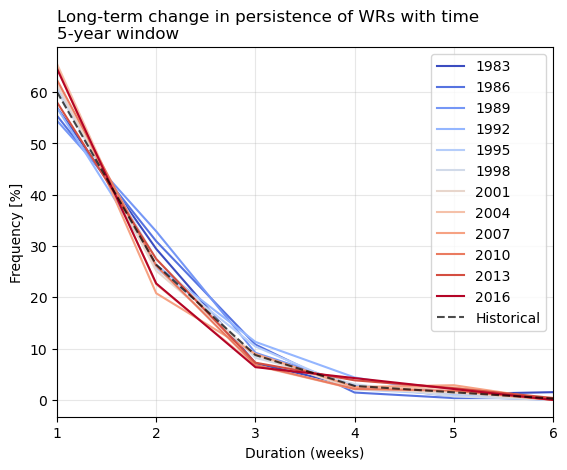

In [222]:
center_years = np.arange(1983,2019,3)
hist_durations = np.zeros([len(mid_bins),len(center_years)])

for iyear,year in enumerate(center_years):
    df_temp = initial_df[(initial_df.index.year>=year-2)&(initial_df.index.year<=year+2)]
    
    monday_df = df_temp[df_temp.index.day_of_week==0]
    thursday_df = df_temp[df_temp.index.day_of_week==3]
    
    hist_monday = get_durations_histogram(monday_df)
    hist_thursday = get_durations_histogram(thursday_df)
    hist_temp = hist_monday+hist_thursday
    hist_temp = hist_temp/np.sum(hist_temp)
    
    hist_durations[:,iyear] = hist_temp
    
n = len(center_years)
colors = plt.cm.coolwarm(np.linspace(0,1,n))

for iyear,year in enumerate(center_years):
    plt.plot(mid_bins,hist_durations[:,iyear]*100,color=colors[iyear],label=year)


plt.plot(mid_bins,hist_total*100,color='k',label='Historical',alpha=0.7,ls='--')

plt.legend()
plt.grid(alpha=0.3)
plt.xlim(1,6)
plt.ylabel('Frequency [%]')
plt.xlabel('Duration (weeks)')
plt.title('Long-term change in persistence of WRs with time\n5-year window',loc='left')

# Seasonal changes in frequency

In [223]:
initial_df = df_shifts['week0'].dropna()

In [224]:
names_seasons = ['Winter','Spring','Summer','Fall']

In [225]:
df_winter = initial_df[(initial_df.index.month==12)|\
            (initial_df.index.month==1)|\
            (initial_df.index.month==2)]
df_spring = initial_df[(initial_df.index.month==3)|\
            (initial_df.index.month==4)|\
            (initial_df.index.month==5)]
df_summer = initial_df[(initial_df.index.month==6)|\
            (initial_df.index.month==7)|\
            (initial_df.index.month==8)]
df_fall = initial_df[(initial_df.index.month==9)|\
            (initial_df.index.month==10)|\
            (initial_df.index.month==11)]

In [226]:
freq_winter = df_winter.dropna().value_counts().sort_index()
freq_winter = freq_winter/np.sum(freq_winter)

freq_spring = df_spring.dropna().value_counts().sort_index()
freq_spring = freq_spring/np.sum(freq_spring)

freq_summer = df_summer.dropna().value_counts().sort_index()
freq_summer = freq_summer/np.sum(freq_summer)

freq_fall = df_fall.dropna().value_counts().sort_index()
freq_fall = freq_fall/np.sum(freq_fall)

In [227]:
names_wr = ['WR1: IH','WR2: PH', 'WR3: IL', 'WR4: PL', 'WR5: Clima']

Text(0.0, 1.0, 'Seasonal changes in frequency')

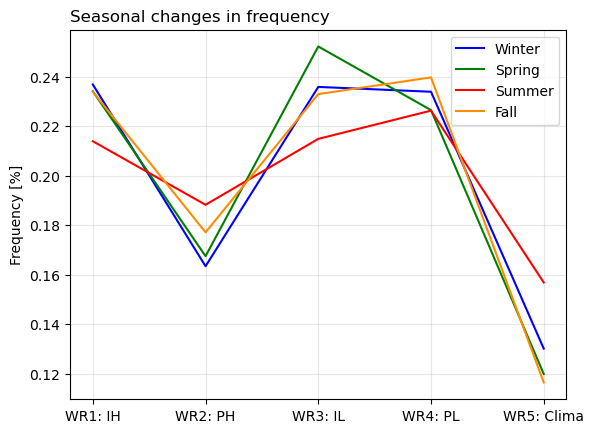

In [228]:
plt.plot(names_wr,freq_winter,color='blue',label='Winter')
plt.plot(names_wr,freq_spring,color='green',label='Spring')
plt.plot(names_wr,freq_summer,color='red',label='Summer')
plt.plot(names_wr,freq_fall,color='darkorange',label='Fall')

plt.legend()
plt.grid(alpha=0.3)
plt.ylabel('Frequency [%]')
# plt.xlabel('Duration (weeks)')
plt.title('Seasonal changes in frequency',loc='left')

# Seasonal changes in persistence

In [229]:
initial_df = df_shifts['week0'].dropna()

In [230]:
names_seasons = ['Winter','Spring','Summer','Fall']

In [231]:
df_winter = initial_df[(initial_df.index.month==12)|\
            (initial_df.index.month==1)|\
            (initial_df.index.month==2)]
df_spring = initial_df[(initial_df.index.month==3)|\
            (initial_df.index.month==4)|\
            (initial_df.index.month==5)]
df_summer = initial_df[(initial_df.index.month==6)|\
            (initial_df.index.month==7)|\
            (initial_df.index.month==8)]
df_fall = initial_df[(initial_df.index.month==9)|\
            (initial_df.index.month==10)|\
            (initial_df.index.month==11)]

In [232]:
hist_durations_seasons = np.zeros([len(mid_bins),4])

for iseason,df_temp in enumerate([df_winter,df_spring,df_summer,df_fall]):    
    monday_df = df_temp[df_temp.index.day_of_week==0]
    thursday_df = df_temp[df_temp.index.day_of_week==3]
    
    hist_monday = get_durations_histogram(monday_df)
    hist_thursday = get_durations_histogram(thursday_df)
    hist_temp = hist_monday+hist_thursday
    hist_temp = hist_temp/np.sum(hist_temp)
    
    hist_durations_seasons[:,iseason] = hist_temp

Text(0.0, 1.0, 'Seasonal changes in persistence of WRs with time\n(excluding WR 5)')

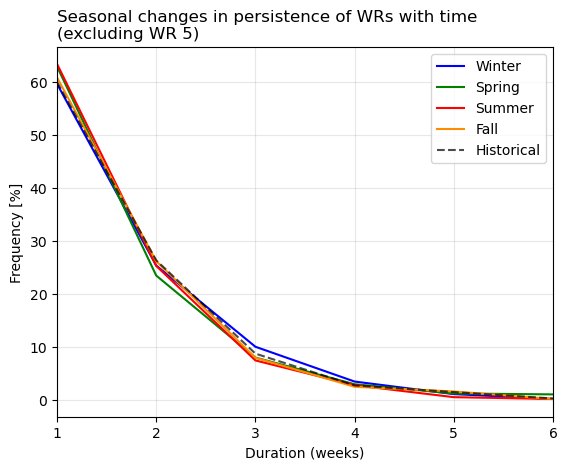

In [233]:
colors_seasons = ['blue','green','red','darkorange']

for iseason in range(len(names_seasons)):    
    plt.plot(mid_bins,hist_durations_seasons[:,iseason]*100,
             color=colors_seasons[iseason],label=names_seasons[iseason])

plt.plot(mid_bins,hist_total*100,color='k',label='Historical',alpha=0.7,ls='--')

plt.legend()
plt.grid(alpha=0.3)
plt.xlim(1,6)
plt.ylabel('Frequency [%]')
plt.xlabel('Duration (weeks)')
plt.title('Seasonal changes in persistence of WRs with time\n(excluding WR 5)',loc='left')

# Seasonal trends in frequency

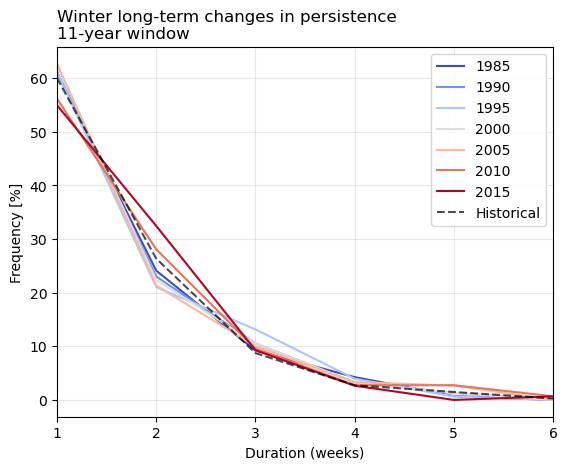

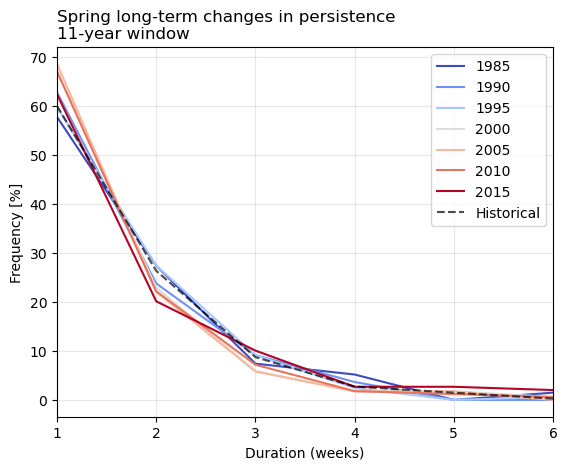

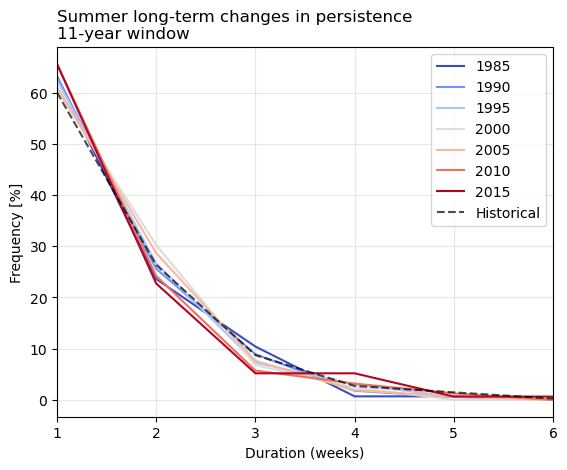

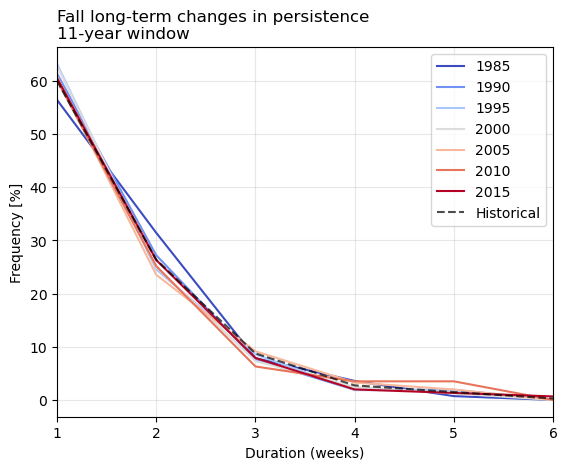

In [234]:
for iseason,df_season in enumerate([df_winter,df_spring,df_summer,df_fall]): 
    center_years = np.arange(1985,2020,5)
    hist_durations = np.zeros([len(mid_bins),len(center_years)])

    for iyear,year in enumerate(center_years):
        df_temp = df_season[(df_season.index.year>=year-5)&(df_season.index.year<=year+5)]

        monday_df = df_temp[df_temp.index.day_of_week==0]
        thursday_df = df_temp[df_temp.index.day_of_week==3]

        hist_monday = get_durations_histogram(monday_df)
        hist_thursday = get_durations_histogram(thursday_df)
        hist_temp = hist_monday+hist_thursday
        hist_temp = hist_temp/np.sum(hist_temp)

        hist_durations[:,iyear] = hist_temp

    n = len(center_years)
    colors = plt.cm.coolwarm(np.linspace(0,1,n))

    for iyear,year in enumerate(center_years):
        plt.plot(mid_bins,hist_durations[:,iyear]*100,color=colors[iyear],label=year)


    plt.plot(mid_bins,hist_total*100,color='k',label='Historical',alpha=0.7,ls='--')

    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(1,6)
    plt.ylabel('Frequency [%]')
    plt.xlabel('Duration (weeks)')
    plt.title(f'{names_seasons[iseason]} long-term changes in persistence\n11-year window',loc='left')
    plt.show()
    plt.close('all')

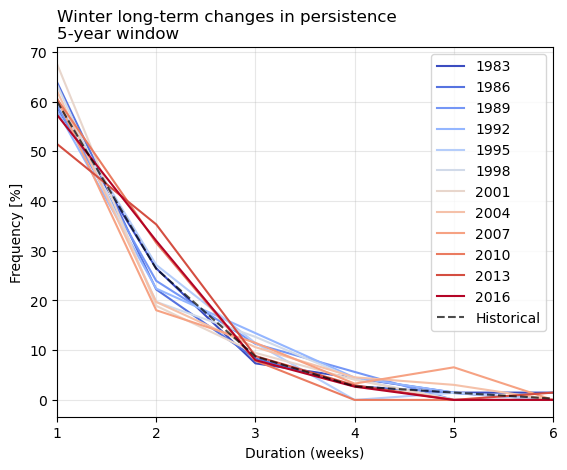

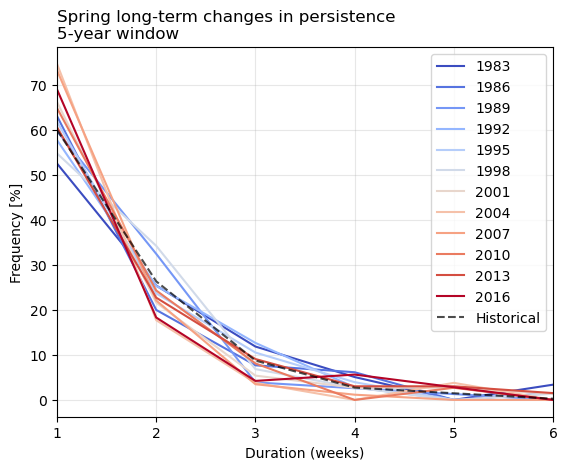

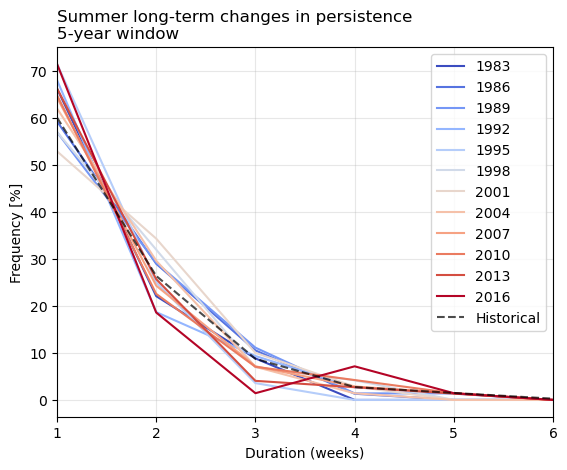

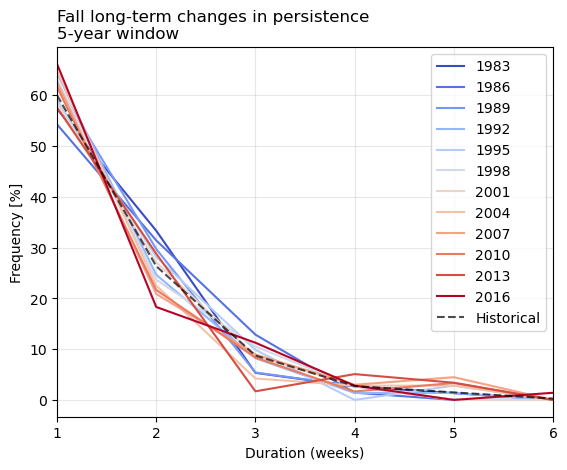

In [235]:
for iseason,df_season in enumerate([df_winter,df_spring,df_summer,df_fall]): 
    center_years = np.arange(1983,2019,3)
    hist_durations = np.zeros([len(mid_bins),len(center_years)])

    for iyear,year in enumerate(center_years):
        df_temp = df_season[(df_season.index.year>=year-2)&(df_season.index.year<=year+2)]

        monday_df = df_temp[df_temp.index.day_of_week==0]
        thursday_df = df_temp[df_temp.index.day_of_week==3]

        hist_monday = get_durations_histogram(monday_df)
        hist_thursday = get_durations_histogram(thursday_df)
        hist_temp = hist_monday+hist_thursday
        hist_temp = hist_temp/np.sum(hist_temp)

        hist_durations[:,iyear] = hist_temp

    n = len(center_years)
    colors = plt.cm.coolwarm(np.linspace(0,1,n))

    for iyear,year in enumerate(center_years):
        plt.plot(mid_bins,hist_durations[:,iyear]*100,color=colors[iyear],label=year)


    plt.plot(mid_bins,hist_total*100,color='k',label='Historical',alpha=0.7,ls='--')

    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(1,6)
    plt.ylabel('Frequency [%]')
    plt.xlabel('Duration (weeks)')
    plt.title(f'{names_seasons[iseason]} long-term changes in persistence\n5-year window',loc='left')
    plt.show()
    plt.close('all')

# seasonal trend in frequency of class 5: mean-state

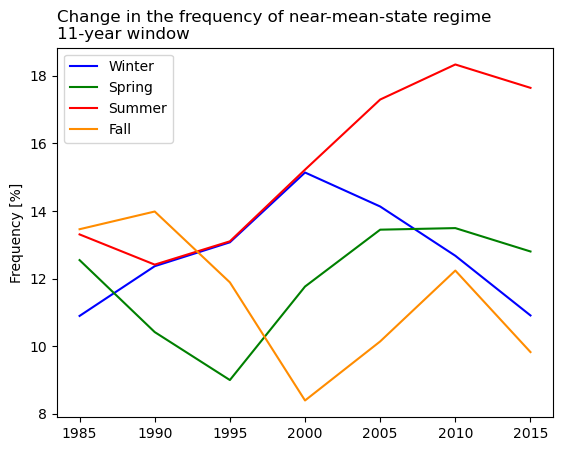

In [259]:
center_years = np.arange(1985,2020,5)
freq_class5 = np.zeros([4,len(center_years)])

for iseason,df_season in enumerate([df_winter,df_spring,df_summer,df_fall]): 
    for iyear,year in enumerate(center_years):
        df_temp = df_season[(df_season.index.year>=year-5)&(df_season.index.year<=year+5)]
        freq_temp = len(df_temp[df_temp==4])/len(df_temp)
        freq_class5[iseason,iyear] = freq_temp
        
for iseason in range(len(names_seasons)):
    plt.plot(center_years,freq_class5[iseason]*100,
             color=colors_seasons[iseason], label= names_seasons[iseason])
plt.legend()
plt.ylabel('Frequency [%]')
plt.title(f'Change in the frequency of near-mean-state regime\n11-year window',loc='left')
plt.show()

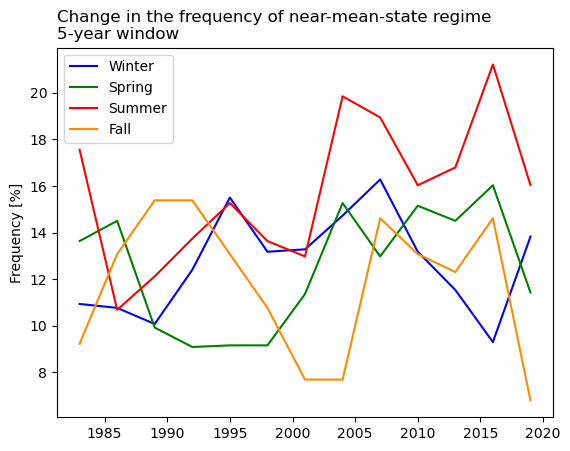

In [260]:
center_years = np.arange(1983,2020,3)
freq_class5 = np.zeros([4,len(center_years)])
for iseason,df_season in enumerate([df_winter,df_spring,df_summer,df_fall]): 
    for iyear,year in enumerate(center_years):
        df_temp = df_season[(df_season.index.year>=year-2)&(df_season.index.year<=year+2)]
        freq_temp = len(df_temp[df_temp==4])/len(df_temp)
        freq_class5[iseason,iyear] = freq_temp
        
for iseason in range(len(names_seasons)):
    plt.plot(center_years,freq_class5[iseason]*100,
             color=colors_seasons[iseason], label= names_seasons[iseason])
plt.legend()
plt.ylabel('Frequency [%]')
plt.title(f'Change in the frequency of near-mean-state regime\n5-year window',loc='left')
plt.show()

In [1]:
a

NameError: name 'a' is not defined